In [1]:
import geopandas as gpd
import pandas as pd
import os
import json
import csv
from mpl_toolkits.basemap import Basemap
import numpy as np
import math,numbers
gdf = gpd.read_file("gsom.kml")
#print(gdf)
import matplotlib.pyplot as plt

ERROR 1: libpoppler.so.140: cannot open shared object file: No such file or directory
ERROR 1: libpoppler.so.140: cannot open shared object file: No such file or directory


In [ ]:
gdf.columns

In [ ]:
type(gdf)

In [ ]:
from shapely.geometry import Polygon

In [2]:
lat1=37.0
lat2=41.1
lon1=250.9
lon2=258
lon1=-(360-lon1)
lon2=-(360-lon2)
print(lon1,lon2)

-109.1 -102


In [ ]:
polygon = Polygon([(lon1, lat1), (lon2,lat1), (lon2,lat2), (lon1,lat2)])

In [ ]:
points_within = gdf[gdf.within(polygon)]

In [ ]:
points_within["Description"]

In [ ]:
hist={}
stns=[]
for indx,row in points_within.iterrows():
    a=pd.read_html(row["Description"])
    for val in a[0][0].values.tolist():
        spl=val.split(":")
        if spl[0].strip() == "ID":
           stns.append(spl[2].strip())
           tp = spl[1].strip()
           if tp not in hist:
               hist[tp]=0
           hist[tp]+=1
        print(spl)
   

In [ ]:
hit=0
miss=0
hist={}
for stn in stns:
   file=f"data/Gsom/{stn}.csv"
    
   if os.path.isfile(file):
      hit+=1
      fin = open(file)
      csv_reader = csv.DictReader(fin)
      rows = [row for row in csv_reader]
      fin.close()
      for row in rows:
          stn=row["STATION"]
          dte=row["DATE"].split("-")
          yr=dte[0]
          mo=dte[1]
          if stn not in hist:
              hist[stn]={}
          if yr not in hist[stn]:
              hist[stn][yr]={}
          hist[stn][yr][mo]=1
      
   else:
      miss+=1
print(hit,miss)     

In [ ]:
sumry={}
for stn,dct in hist.items():
    sumry[stn]={}
    for year,invt in dct.items():
        sumry[stn][year]=len(invt)
        

In [ ]:
sumry

### GHCND Inventory vs Files

In [ ]:
fin = open("ghcnd-stations.txt")
stations = {}
for line in fin:
    spl = line.split("\t")
    # lat = spl[1]
    # lon = spl[2]
    
    id = line[:11].strip()
    lat = line[12:20]
    lon = line[21:30]
    elv = line[30:37]
    stat = line[38:40]
    name = line[41:].replace("\n","")
    if stat == "CO":
        stations[id]={}
        stations[id]['lat']=lat
        stations[id]['lon']=lon
        stations[id]['lev']=elv
        stations[id]['state']=stat
        stations[id]['name']=name
        

In [73]:
hit=0
miss=0
hist={}
varHist={}
varStns={}
for stn,info in stations.items():
   file=f"data/Gsom/{stn}.csv"
    
   if os.path.isfile(file):
      fin = open(file)
      csv_reader = csv.DictReader(fin)
      rows = [row for row in csv_reader]
      fin.close()
      for row in rows:
          stn=row["STATION"]
          dte=row["DATE"].split("-")
          yr=int(dte[0])
          mo=int(dte[1])
          if yr < 1800:
              print(stn,dte)
          if stn not in hist:
              hist[stn]={}
          if yr not in hist[stn]:
              hist[stn][yr]={}
          hist[stn][yr][mo]=1
          for col,val in row.items():
              if col.find("ATTRIBUTES") < 0:
                  if (isinstance(val, numbers.Number) and not math.isnan(val)) or isinstance(val,str):
                    if col not in varHist:
                        varHist[col]={}
                        varStns[col]={}
                        
                    if yr not in varHist[col]:
                        varHist[col][yr]={}
                        varStns[col][yr]={}
                        
                    if mo not in varHist[col][yr]:
                        varHist[col][yr][mo]=0
                    if stn not in varStns[col][yr]:
                        varStns[col][yr][stn]=0
                
                    varHist[col][yr][mo]+=1
                    varStns[col][yr][stn]+=1
                      
                    
       
          
print(hit,miss)      

0 0


In [ ]:
min(varHist["STATION"].keys())

In [67]:
varHist.keys()

dict_keys(['STATION', 'DATE', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'NAME', 'DP01', 'DP10', 'DP1X', 'DSND', 'DSNW', 'DYSD', 'DYSN', 'DYXP', 'EMSD', 'EMSN', 'EMXP', 'PRCP', 'SNOW', 'CDSD', 'CLDD', 'DT00', 'DT32', 'DX32', 'DX70', 'DX90', 'DYFG', 'DYNT', 'DYTS', 'DYXT', 'EMNT', 'EMXT', 'HDSD', 'HTDD', 'TAVG', 'TMAX', 'TMIN', 'AWND', 'EVAP', 'MNPN', 'MXPN', 'WDMV', 'WDFG', 'WSFG', 'HX01', 'LX01', 'MX01', 'WDF2', 'WDF5', 'WSF2', 'WSF5', 'DYHF', 'TSUN', 'ADPT', 'ASLP', 'ASTP', 'AWBT', 'RHAV', 'RHMN', 'RHMX', 'PSUN', 'WDF1', 'WSF1', 'WDFM', 'WSFM'])

In [97]:
sumry={}
get=["RHAV","RHMN","RHMX"]
get=["EVAP"]
get=["RHAV"]
get=["TSUN"]
get=["TAVG"]
get=["AWND"]
get=["AWBT"]
get=["PRCP"]




for var,dct in varHist.items():
#    print(var)
    if var in get:
#        print(var,var.find("R"))
        yrmn = min(dct.keys())
        sumry[var]={}
        momn = min(dct[yrmn].keys())
        yrmx = max(dct.keys())
        momx = max(dct[yrmx].keys())
        print(f"{var:15s}")
        for year in range(yrmn,yrmx+1):
            if year in dct:
               print(f"{year:4d}",end="")
               for month in range(1,13):
                   if month in dct[year]:
                       cnt=dct[year][month]
                   else:
                       cnt=0
                   print(f"{cnt:6d}",end="")
            print("")       
        print("----------------------------------------\n")
    #print(var,yrmn,yrmx)

PRCP           
1852     0     0     0     0     0     0     0     0     0     1     1     1
1853     1     1     1     1     1     0     0     0     1     0     0     0
1854     0     0     0     0     0     1     1     1     1     1     0     1
1855     0     0     1     1     1     1     1     0     1     0     1     1
1856     1     1     1     1     1     1     1     1     1     1     1     1
1857     1     1     1     1     1     1     1     1     1     1     1     1
1858     1     1     1     1     1     1     1     0     1     0     1     1
1859     1     1     1     0     1     1     1     1     1     1     1     1
1860     1     1     1     1     0     1     1     1     1     1     1     1
1861     1     1     1     1     1     1     1     1     1     1     1     0
1862     1     1     1     1     1     1     1     1     1     1     1     1
1863     1     1     1     0     1     1     1     1     1     1     1     1
1864     1     1     0     0     0     0     0     0     0  

In [119]:
lats=[]
lons=[]
get=["EVAP"]
get=["TSUN"]
get=["PRCP","TAVG","TMIN","TMAX","AWND","EVAP","AWBT","RHAV","RHMN","RHMX"]
allLocs={}
years=[1952,1960,1980,1997]
hold={}
for yr in years:
    hold[yr]=[]
hold["Variable"]=[]
for col in get:
    allLocs[col]={}
    hold["Variable"].append(col)
    for year in years:
        total=0
        for stn,cnt in varStns[col][year].items():
            if cnt > 10:
      #          print("   ",stn)
                total+=1
                lats.append(float(stations[stn]["lat"]))
                lons.append(float(stations[stn]["lon"]))
                if year not in allLocs[col]:
                    allLocs[col][year]={}
                    allLocs[col][year]["lats"]=[]
                    allLocs[col][year]["lons"]=[]
                allLocs[col][year]["lats"].append(float(stations[stn]["lat"]))
                allLocs[col][year]["lons"].append(float(stations[stn]["lon"]))
        hold[year].append(total)
                
            
    
    

In [116]:
hold

{1952: [16, 166, 166, 166, 12, 5, 200, 5, 5, 5],
 1960: [18, 162, 162, 162, 13, 6, 193, 6, 6, 6],
 1980: [21, 177, 177, 177, 13, 6, 192, 6, 6, 6],
 1997: [21, 312, 312, 312, 24, 10, 290, 10, 10, 10],
 'Variable': ['EVAP',
  'TAVG',
  'TMIN',
  'TMAX',
  'AWND',
  'AWBT',
  'PRCP',
  'RHAV',
  'RHMN',
  'RHMX']}

In [120]:
dfSum = pd.DataFrame({
    "Variable":hold["Variable"],
     "1950":hold[1952],
     "1960":hold[1960],
    "1980":hold[1980],
    "1997":hold[1997]})

In [121]:
display(dfSum.T.head(100))

,0,1,2,3,4,5,6,7,8,9
Variable,PRCP,TAVG,TMIN,TMAX,AWND,EVAP,AWBT,RHAV,RHMN,RHMX
1950,200,166,166,166,12,16,5,5,5,5
1960,193,162,162,162,13,18,6,6,6,6
1980,192,177,177,177,13,21,6,6,6,6
1997,290,312,312,312,24,21,10,10,10,10


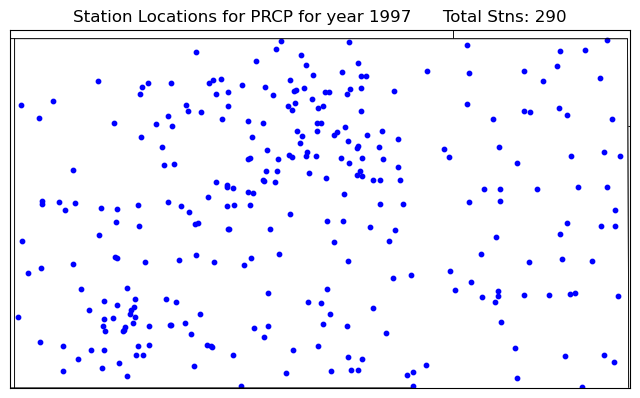

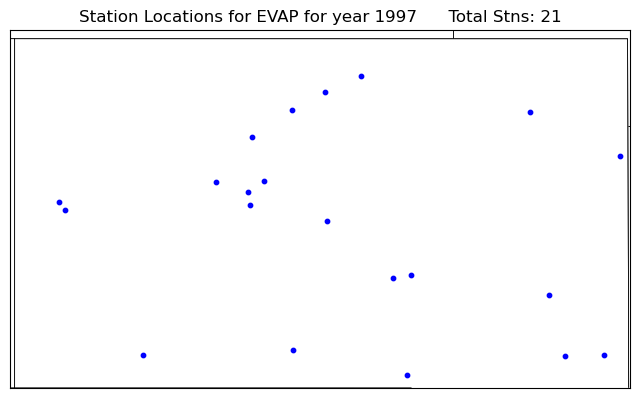

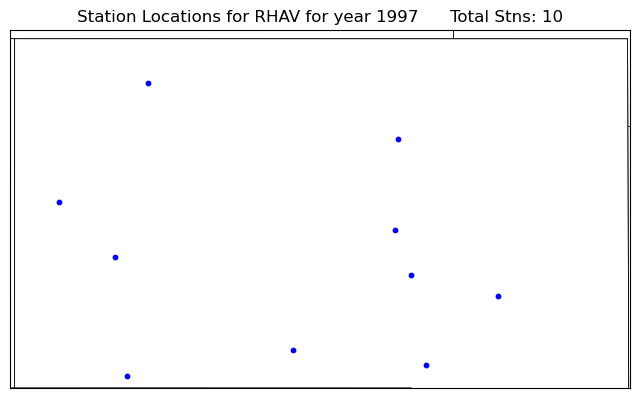

In [128]:
var="PRCP"
year=1997

vars=["PRCP","EVAP","RHAV"]
for var in vars:
    lats=allLocs[var][year]["lats"]
    lons=allLocs[var][year]["lons"]
    fig = plt.figure(figsize=(8, 6), edgecolor='b')
    lat1=37.0
    lat2=41.1
    lon1=250.9
    lon2=258
    # lon1=-(360-lon1)
    # lon2=-(360-lon2)
    my_map = Basemap(projection='cyl',
                   llcrnrlat=lat1, urcrnrlat=lat2,resolution="l",
                llcrnrlon=lon1, urcrnrlon=lon2)
     
    #my_map.drawcoastlines()
    my_map.drawstates()
    my_map.scatter(lons, lats, latlon=True,c="blue",s=10)
    plt.title(f"Station Locations for {var} for year {year}      Total Stns: {len(lats)}")


In [ ]:
histCols={}
for stn,info in stations.items():
   file=f"data/Gsom/{stn}.csv"
    
   if os.path.isfile(file):
      df = pd.read_csv(file)
      for col in df.columns:
          if col not in histCols:
              histCols[col]=0
          histCols[col]+=1
              

In [ ]:
df

In [ ]:
histCols

In [ ]:
row

In [ ]:
len(hist)

In [ ]:
hist

In [ ]:
sumry={}
for stn,dct in hist.items():
    sumry[stn]={}
    for year,invt in dct.items():
        sumry[stn][year]=len(invt)

In [ ]:
cnt1950=0
cnt1960=0
cnt1970=0
cnt1980=0
cnt1990=0
stns1950=[]
stns1960=[]
stns1970=[]
stns1980=[]
stns1990=[]

for stn,dct in sumry.items():
      good=0
      bad=0
      nyrs=0
      yrs=list(dct.keys())
      yrmn=min(yrs)
      yrmx=max(yrs)
    
      for year,cnt in dct.items():
          if cnt > 10:
              good+=1
          else:
              bad+=1
          nyrs+=1
      if yrmx > 2023:
        myrs = yrmx-yrmn+1
#        print(stn,good,bad,yrmn,yrmx,myrs,nyrs)

        if yrmn < 1960 and abs(nyrs-myrs) < 2:
           cnt1950+=1
           stns1950.append(stn)
        if yrmn < 1970 and abs(nyrs-myrs) < 2:
           cnt1960+=1
           stns1960.append(stn)
        if yrmn < 1980 and abs(nyrs-myrs) < 2:
           cnt1970+=1
           stns1970.append(stn)
            
        if yrmn < 1990 and abs(nyrs-myrs) < 2:
           cnt1980+=1
           stns1980.append(stn)
            
        if yrmn < 2000 and abs(nyrs-myrs) < 2:
           cnt1990+=1
           stns1990.append(stn)
            
            
        
print(cnt1950,cnt1960,cnt1970,cnt1980,cnt1990)           

In [ ]:
print(cnt1950,cnt1960,cnt1970,cnt1980,cnt1990)           

In [ ]:
len(stns1950)

In [ ]:
fin = open("ghcnd-stations.txt")
stations = {}
for line in fin:
    spl = line.split("\t")
    # lat = spl[1]
    # lon = spl[2]
    
    id = line[:11]
    lat = line[12:20]
    lon = line[21:30]
    elv = line[30:37]
    stat = line[38:40]
    name = line[41:].replace("\n","")
    if stat == "CO":
        print(stat,line)
        stations[id]={}
        stations[id]['lat']=lat
        stations[id]['lon']=lon
        stations[id]['lev']=elv
        stations[id]['state']=stat
        stations[id]['name']=name

In [ ]:
len(stations)

In [ ]:
lons=[]
lats=[]
for station in stns1980:
#    print(station,stations[station]["lat"],stations[station]["lon"],stations[station]["name"])
    lons.append(float(stations[station]["lon"]))
    lats.append(float(stations[station]["lat"]))
    

In [ ]:
#X,Y = np.meshgrid(lons,lats)
fig = plt.figure(figsize=(8, 6), edgecolor='b')
lat1=37.0
lat2=41.1
lon1=250.9
lon2=258
# lon1=-(360-lon1)
# lon2=-(360-lon2)
my_map = Basemap(projection='cyl',
               llcrnrlat=lat1, urcrnrlat=lat2,resolution="l",
            llcrnrlon=lon1, urcrnrlon=lon2)
 
#my_map.drawcoastlines()
my_map.drawstates()
my_map.scatter(lons, lats, latlon=True,c="blue",s=10)


